In [1]:
pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

X_TBM = pd.read_csv('data_A1/X_TBM.csv')
y_TBM = pd.read_csv('data_A1/y_TBM.csv')

In [4]:
# --- Core libraries ---
import numpy as np
import pandas as pd

# --- Train/test split & cross-validation ---
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

# --- Tree-based models ---
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# XGBoost and LightGBM (install if not yet available: pip install xgboost lightgbm)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- Evaluation metrics ---
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

# --- Feature importance / interpretability ---
from sklearn.inspection import permutation_importance

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Misc ---
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [5]:
# --- Basic shape check ---
print("X_TBM shape:", X_TBM.shape)
print("y_TBM shape:", y_TBM.shape)
print("\ny_TBM columns:", list(y_TBM.columns))

# --- Isolate main target ---
target_col = "Severity"
y = y_TBM[target_col]

# --- Class balance ---
print("\nClass counts:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True).round(3))

X_TBM shape: (774, 82)
y_TBM shape: (774, 3)

y_TBM columns: ['Management', 'Severity', 'Diagnosis']

Class counts:
Severity
0    659
1    115
Name: count, dtype: int64

Class proportions:
Severity
0    0.851
1    0.149
Name: proportion, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split

X = X_TBM.copy()
y = y_TBM[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "| Positive rate:", y_train.mean().round(3))
print("Test shape:", X_test.shape, "| Positive rate:", y_test.mean().round(3))

Train shape: (619, 82) | Positive rate: 0.149
Test shape: (155, 82) | Positive rate: 0.148


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 5-fold stratified CV, shuffled for randomness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Metrics we care about for a medical diagnosis task:
# - recall: catching actual appendicitis cases (minimize false negatives)
# - precision: avoid unnecessary interventions (minimize false positives)
# - f1: balance of both
# - roc_auc: overall discriminative ability
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [8]:
def evaluate_model_cv(model, X_train, y_train, cv, scoring, model_name="Model"):
    """
    Runs cross-validation for a given model and returns mean/std of each metric.
    Also returns the raw cv_results dict in case you want per-fold detail.
    """
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,   # lets us check overfitting (train vs val gap)
        n_jobs=-1
    )
    
    summary = {"model": model_name}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]
        summary[f"{metric}_val_mean"] = test_scores.mean()
        summary[f"{metric}_val_std"] = test_scores.std()
        summary[f"{metric}_train_mean"] = train_scores.mean()
    
    return pd.DataFrame([summary]), cv_results

In [9]:
dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)

results_df, raw_cv = evaluate_model_cv(
    dt_baseline, X_train, y_train, cv, scoring, model_name="Decision Tree (baseline)"
)

results_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (baseline),0.8853,0.020644,1.0,0.62787,0.081567,1.0,0.609357,0.077242,1.0,0.612527,0.054117,1.0,0.771507,0.035342,1.0


In [10]:
# Fit an unconstrained tree to get the full pruning path
full_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Number of candidate alpha values: {len(ccp_alphas)}")
print(f"Alpha range: {ccp_alphas.min():.6f} to {ccp_alphas.max():.6f}")

Number of candidate alpha values: 24
Alpha range: 0.000000 to 0.124954


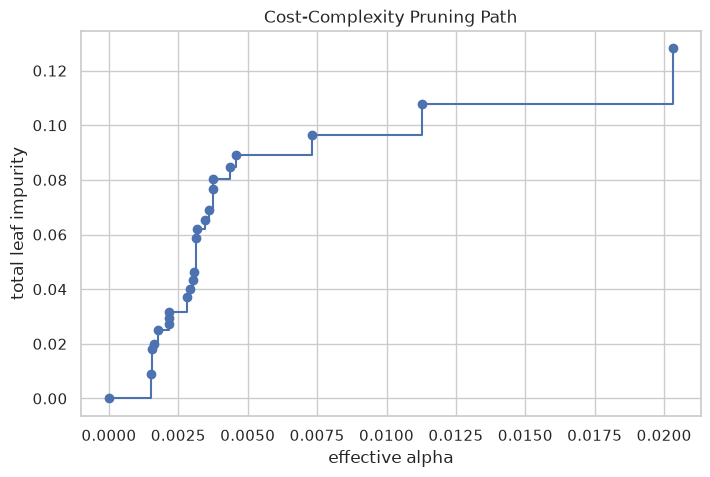

In [11]:
# Plot alpha vs. total impurity of leaves (helps visualize the tradeoff)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total leaf impurity")
ax.set_title("Cost-Complexity Pruning Path")
plt.show()

In [12]:
# For each candidate alpha, fit a tree and check its CV F1 score
# We skip the very last alpha (it prunes to a single-node tree, which is trivial)
from sklearn.model_selection import cross_val_score

alpha_results = []
for alpha in ccp_alphas[:-1]:
    tree = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    scores = cross_val_score(tree, X_train, y_train, cv=cv, scoring="f1")
    alpha_results.append({
        "ccp_alpha": alpha,
        "f1_val_mean": scores.mean(),
        "f1_val_std": scores.std(),
        "n_leaves": tree.fit(X_train, y_train).get_n_leaves()
    })

alpha_df = pd.DataFrame(alpha_results)
alpha_df.sort_values("f1_val_mean", ascending=False).head(10)

,ccp_alpha,f1_val_mean,f1_val_std,n_leaves
20,0.007330,0.742890,0.079932,4
21,0.011279,0.713228,0.089824,3
19,0.004595,0.675678,0.058529,5
18,0.004362,0.655811,0.075696,6
22,0.020304,0.639414,0.073473,2
16,0.003742,0.621002,0.051516,8
17,0.003751,0.621002,0.051516,7
15,0.003590,0.621002,0.051516,10
7,0.002154,0.618944,0.048990,22
6,0.002154,0.618944,0.048990,22


## Interpreting the Severity pruning path

Compare this to the Diagnosis pruning path we ran earlier. Two clear differences stand out:

1. **Much lower F1 overall.** Best F1 here is ~0.743, versus ~0.941 for Diagnosis.
   Expected, given the much stronger class imbalance and far fewer positive examples
   to learn from (~92 in training vs. ~366 for Diagnosis) -- not a sign anything is
   broken, just a harder, more data-starved problem.

2. **Much higher f1_val_std.** 0.080 here vs. ~0.016-0.019 for Diagnosis -- roughly
   4-5x noisier. This directly reflects what we discussed: with only ~18 positive
   cases per validation fold, a couple of flipped predictions swings F1 substantially.
   Take any single "best" alpha with a grain of salt; the difference between the
   top several rows is well within one standard deviation of each other.

3. **Best trees are much simpler.** Top result has only 4 leaves (ccp_alpha=0.0073),
   compared to 18-26 leaves for Diagnosis's best trees. This makes sense: with so few
   positive examples, a complex tree has very little signal to carve fine-grained
   splits from -- aggressive pruning avoids overfitting to a handful of severe cases
   that happen to land in the training folds.

In [13]:
from sklearn.model_selection import GridSearchCV

# Narrowed-down parameter grid, informed by what we just saw
param_grid = {
    "max_depth": [3, 5, 7,9, 10, 11,12,15,None ],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0.0, 0.0015, 0.002, 0.0025],
    # For Decision Tree / Random Forest, add to param grids:
    "class_weight": [None, "balanced"]
}

dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",          # optimize for F1 (balances precision/recall)
    cv=cv,                 # same StratifiedKFold as before, for consistency
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

dt_grid_search.fit(X_train, y_train)

print("Best params:", dt_grid_search.best_params_)
print("Best CV F1:", dt_grid_search.best_score_)

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Best params: {'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV F1: 0.7823953823953824


In [14]:
best_dt = dt_grid_search.best_estimator_

results_df, raw_cv = evaluate_model_cv(
    best_dt, X_train, y_train, cv, scoring, model_name="Decision Tree (tuned)"
)

results_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (tuned),0.937031,0.015543,0.94871,0.81078,0.082006,0.854714,0.760234,0.057655,0.790818,0.782395,0.053584,0.82086,0.937734,0.019767,0.983723


## Random Forest — Baseline

Random Forest builds many decision trees on bootstrapped samples of the training data,
each tree also considering only a random subset of features at each split. Predictions
are aggregated (majority vote for classification). This reduces variance compared to a
single tree, since errors from individual overfit trees tend to average out.

We start with a baseline (mostly default parameters) to get a reference point before tuning.

In [15]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,       # number of trees in the forest
    random_state=RANDOM_STATE,
    n_jobs=-1                # use all CPU cores
)

results_rf_baseline, raw_cv_rf = evaluate_model_cv(
    rf_baseline, X_train, y_train, cv, scoring, model_name="Random Forest (baseline)"
)

results_rf_baseline

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Random Forest (baseline),0.927301,0.016131,1.0,0.875238,0.109188,1.0,0.608187,0.065981,1.0,0.712745,0.060686,1.0,0.963639,0.012698,1.0


In [16]:
comparison_df = pd.concat([results_df, results_rf_baseline], ignore_index=True)
comparison_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (tuned),0.937031,0.015543,0.94871,0.810780,0.082006,0.854714,0.760234,0.057655,0.790818,0.782395,0.053584,0.82086,0.937734,0.019767,0.983723
1,Random Forest (baseline),0.927301,0.016131,1.00000,0.875238,0.109188,1.000000,0.608187,0.065981,1.000000,0.712745,0.060686,1.00000,0.963639,0.012698,1.000000


## Random Forest hyperparameters

Random Forest adds new hyperparameters on top of the Decision Tree ones we already know
(`max_depth`, `min_samples_split`, `min_samples_leaf`):

- **n_estimators**: number of trees in the forest. More trees generally reduce variance
  and stabilize predictions, with diminishing returns past a certain point (and rising
  compute cost). Rarely causes overfitting by itself -- unlike tree depth, adding more
  trees does not make the *ensemble* more prone to memorizing training data.

- **max_features**: number of features considered at each split, chosen randomly per split.
  This is what decorrelates the trees -- if every tree could see all features, they'd tend
  to make similar splits on the strongest predictors and end up highly correlated (which
  would defeat the variance-reduction benefit of averaging). Common choices: "sqrt"
  (default for classification, uses sqrt(n_features) per split), "log2", or a float
  (fraction of features), or an int (fixed number of features).

- **max_samples**: if bootstrap=True (default), this controls what fraction of the training
  set each tree is built on (default is the full dataset size, sampled with replacement).
  Lowering it increases diversity between trees (more variance reduction) but each tree
  sees less data.

- **bootstrap**: whether trees are built on bootstrap samples (True, default) or the full
  dataset (False). Almost always left True -- it's what makes "bagging" bagging.

We'll reuse max_depth, min_samples_split, min_samples_leaf, and ccp_alpha from before,
now combined with n_estimators and max_features.

## Random Forest — Randomized Search

A full grid search here would be expensive: Random Forest fits are much slower than a
single Decision Tree (n_estimators trees per fit), and we now have 6 hyperparameters
instead of 4. We use RandomizedSearchCV instead, which samples a fixed number of
random combinations rather than trying every combination exhaustively.

In [17]:
from scipy.stats import randint

param_dist_rf = {
    "n_estimators": randint(100, 600),
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "bootstrap": [True],
    "class_weight": [None, "balanced"]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=100,             # number of random combinations to try
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    random_state=RANDOM_STATE,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("Best params:", rf_random_search.best_params_)
print("Best CV F1:", rf_random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'bootstrap': True, 'class_weight': None, 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 17, 'n_estimators': 559}
Best CV F1: 0.7852651694756958


## Is it worth narrowing max_depth further?

Before running another expensive search, let's look at what RandomizedSearchCV already
tried. We have 100 sampled combinations with their CV F1 scores sitting in
`rf_random_search.cv_results_` -- no need to guess, we can check whether max_depth
actually shows a trend worth chasing.

In [18]:
cv_results_rf = pd.DataFrame(rf_random_search.cv_results_)

# Extract relevant columns, sort by performance
depth_check = cv_results_rf[[
    "param_max_depth", "param_n_estimators", "param_max_features",
    "param_min_samples_leaf", "param_min_samples_split", "mean_test_score"
]].sort_values("mean_test_score", ascending=False)

depth_check.head(15)

,param_max_depth,param_n_estimators,param_max_features,param_min_samples_leaf,param_min_samples_split,mean_test_score
52,5,559,0.5,1,17,0.785265
79,None,353,0.3,4,2,0.784309
60,15,355,0.5,1,2,0.783310
74,5,338,0.5,1,2,0.781972
42,10,575,0.5,1,12,0.780274
9,10,527,0.5,15,8,0.779340
85,15,429,sqrt,1,9,0.778959
59,None,280,0.5,17,15,0.777178
6,15,406,0.5,3,6,0.777128
40,20,246,0.5,4,4,0.776249


In [19]:
best_rf = rf_random_search.best_estimator_

results_rf_tuned, raw_cv_rf_tuned = evaluate_model_cv(
    best_rf, X_train, y_train, cv, scoring, model_name="Random Forest (tuned)"
)

results_rf_tuned

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Random Forest (tuned),0.937031,0.018592,0.972941,0.803041,0.089523,0.936449,0.77076,0.04517,0.877675,0.785265,0.061108,0.906037,0.964646,0.007336,0.99402


In [20]:
# Recompute baseline Decision Tree results (variable was overwritten earlier)
results_dt_baseline, _ = evaluate_model_cv(
    dt_baseline, X_train, y_train, cv, scoring, model_name="Decision Tree (baseline)"
)

# Rebuild comparison table in a clear, fixed order
comparison_df = pd.concat(
    [results_dt_baseline, results_df, results_rf_baseline, results_rf_tuned],
    ignore_index=True
)
comparison_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (baseline),0.885300,0.020644,1.000000,0.627870,0.081567,1.000000,0.609357,0.077242,1.000000,0.612527,0.054117,1.000000,0.771507,0.035342,1.000000
1,Decision Tree (tuned),0.937031,0.015543,0.948710,0.810780,0.082006,0.854714,0.760234,0.057655,0.790818,0.782395,0.053584,0.820860,0.937734,0.019767,0.983723
2,Random Forest (baseline),0.927301,0.016131,1.000000,0.875238,0.109188,1.000000,0.608187,0.065981,1.000000,0.712745,0.060686,1.000000,0.963639,0.012698,1.000000
3,Random Forest (tuned),0.937031,0.018592,0.972941,0.803041,0.089523,0.936449,0.770760,0.045170,0.877675,0.785265,0.061108,0.906037,0.964646,0.007336,0.994020


## Why we haven't touched the test set yet

Back when we set up the train/test split, we agreed: `X_test` / `y_test` stay
completely untouched until final evaluation. Everything so far (CV scores, grid
search, randomized search) only ever saw `X_train` / `y_train`.

This matters because if we peeked at test performance now, and it looked worse
than expected, the temptation would be to go back and tune further -- at which
point the test set stops being an honest, unbiased estimate of real-world
performance and effectively becomes another validation set. Once that happens,
your final reported number is optimistically biased (you'd have implicitly
"fit" to the test set through repeated adjustment).

## XGBoost — Baseline

XGBoost builds trees sequentially (boosting), where each new tree tries to correct
the errors of the previous ones, rather than averaging independent trees like Random
Forest (bagging). This often gives better performance but is more prone to overfitting
if not regularized, since later trees can start fitting noise in the residuals.

In [21]:
xgb_baseline = XGBClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    eval_metric="logloss",   # avoids a warning, doesn't affect training here
    n_jobs=-1
)

results_xgb_baseline, raw_cv_xgb = evaluate_model_cv(
    xgb_baseline, X_train, y_train, cv, scoring, model_name="XGBoost (baseline)"
)

results_xgb_baseline

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,XGBoost (baseline),0.927288,0.018449,1.0,0.774641,0.086089,1.0,0.738012,0.097252,1.0,0.749009,0.067416,1.0,0.964094,0.00282,1.0


## XGBoost hyperparameters

XGBoost builds trees sequentially -- each new tree fits the *residual errors* of the
ensemble so far. This makes its overfitting dynamics different from Random Forest:
more trees can actively hurt generalization (each additional tree keeps chasing
residuals, including noise), whereas in Random Forest more trees just stabilizes
the average.

- **n_estimators**: number of boosting rounds (sequential trees). Unlike Random Forest,
  too many can overfit, since each tree specifically targets remaining errors,
  including noise in the training residuals.

- **learning_rate** (eta): shrinks the contribution of each tree (default 0.3).
  Lower values need more n_estimators to reach the same fit, but each individual
  step is smaller/more conservative -- generally lower learning_rate + more trees
  gives better generalization than few trees with a high learning_rate. Classic
  tradeoff: slower training, better results.

- **max_depth**: max depth of each individual tree (default 6). Since boosting adds
  many trees, each tree is usually kept much shallower than a standalone Decision
  Tree or Random Forest tree -- depth 3-6 is typical, since shallow "weak learners"
  combined sequentially tend to generalize better than a few deep, complex ones.

- **subsample**: fraction of *training rows* randomly sampled (without replacement)
  for each boosting round. Adds randomness similar to Random Forest's bagging,
  reduces overfitting. Default 1.0 (all rows); typical tuning range 0.6-1.0.

- **colsample_bytree**: fraction of *features* randomly sampled for each tree
  (analogous to Random Forest's max_features). Default 1.0; typical range 0.5-1.0.

- **min_child_weight**: minimum sum of instance weights needed in a child node to
  allow a split (roughly analogous to min_samples_leaf, but weighted). Higher values
  = more conservative, less overfitting to small/noisy subgroups.

- **gamma**: minimum loss reduction required to make a further split on a leaf node.
  Higher gamma = more conservative tree growth (a split must "prove" it's worth it
  by reducing loss by at least this much). Default 0 (no restriction).

- **reg_alpha / reg_lambda**: L1 / L2 regularization on the leaf weights (similar role
  to regularization in linear models). Higher values shrink leaf output values,
  reducing overfitting. Defaults: reg_alpha=0, reg_lambda=1.

## XGBoost — Randomized Search

Focusing on the highest-impact hyperparameters, with gamma/reg_alpha/reg_lambda
left at light default-ish ranges to keep the search space manageable.

In [22]:
from scipy.stats import uniform, randint

param_dist_xgb = {
    "n_estimators": randint(100, 600),
    "learning_rate": uniform(0.01, 0.29),      # range: 0.01 - 0.30
    "max_depth": randint(3, 8),                 # range: 3 - 7
    "subsample": uniform(0.6, 0.4),              # range: 0.6 - 1.0
    "colsample_bytree": uniform(0.5, 0.5),       # range: 0.5 - 1.0
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 0.5),                    # light range, default 0
    "reg_alpha": uniform(0, 1),                  # light range, default 0
    "reg_lambda": uniform(0.5, 2),
    # For XGBoost, the equivalent is scale_pos_weight:
    "scale_pos_weight": [1, (659/115)]   # ratio of negative:positive in training data
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1
    ),
    param_distributions=param_dist_xgb,
    n_iter=100,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    random_state=RANDOM_STATE,
    verbose=1
)

xgb_random_search.fit(X_train, y_train)

print("Best params:", xgb_random_search.best_params_)
print("Best CV F1:", xgb_random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'colsample_bytree': np.float64(0.7830186052470381), 'gamma': np.float64(0.07932322382124551), 'learning_rate': np.float64(0.04484774786363623), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 146, 'reg_alpha': np.float64(0.040728802318970136), 'reg_lambda': np.float64(2.2109211680220144), 'scale_pos_weight': 5.730434782608696, 'subsample': np.float64(0.6701321079557354)}
Best CV F1: 0.802580280629061


In [23]:
best_xgb = xgb_random_search.best_estimator_

results_xgb_tuned, raw_cv_xgb_tuned = evaluate_model_cv(
    best_xgb, X_train, y_train, cv, scoring, model_name="XGBoost (tuned)"
)

comparison_df = pd.concat(
    [comparison_df, results_xgb_baseline, results_xgb_tuned], ignore_index=True
)
comparison_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (baseline),0.885300,0.020644,1.000000,0.627870,0.081567,1.000000,0.609357,0.077242,1.000000,0.612527,0.054117,1.000000,0.771507,0.035342,1.000000
1,Decision Tree (tuned),0.937031,0.015543,0.948710,0.810780,0.082006,0.854714,0.760234,0.057655,0.790818,0.782395,0.053584,0.820860,0.937734,0.019767,0.983723
2,Random Forest (baseline),0.927301,0.016131,1.000000,0.875238,0.109188,1.000000,0.608187,0.065981,1.000000,0.712745,0.060686,1.000000,0.963639,0.012698,1.000000
3,Random Forest (tuned),0.937031,0.018592,0.972941,0.803041,0.089523,0.936449,0.770760,0.045170,0.877675,0.785265,0.061108,0.906037,0.964646,0.007336,0.994020
4,XGBoost (baseline),0.927288,0.018449,1.000000,0.774641,0.086089,1.000000,0.738012,0.097252,1.000000,0.749009,0.067416,1.000000,0.964094,0.002820,1.000000
5,XGBoost (tuned),0.935392,0.019046,0.972537,0.740207,0.070459,0.844196,0.879532,0.042870,1.000000,0.802580,0.054331,0.915474,0.968337,0.004479,0.997551


## Next: LightGBM

Same pattern as XGBoost — LightGBM is also gradient boosting, but grows trees
leaf-wise (best-first) rather than level-wise, which tends to be faster and can
reach lower loss with fewer splits, but is more prone to overfitting on smaller
datasets if not constrained (num_leaves is the key parameter to watch here).

## How LightGBM works

LightGBM is a gradient boosting framework, like XGBoost — it builds trees sequentially,
each new tree fitting the residual errors (gradients) of the ensemble so far. The core
boosting idea is the same. What's different is *how* it grows each tree and *how* it
finds splits, which makes it faster and sometimes more accurate on the right kind of data.

In [24]:
import re

def clean_feature_names(df):
    df = df.copy()
    df.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", str(col)) for col in df.columns]
    return df

# Check which names are actually problematic first, for transparency
original_cols = X_train.columns.tolist()
cleaned_cols = [re.sub(r"[^A-Za-z0-9_]+", "_", str(col)) for col in original_cols]

changed = [(orig, new) for orig, new in zip(original_cols, cleaned_cols) if orig != new]
print(f"{len(changed)} column name(s) will be changed:")
for orig, new in changed:
    print(f"  '{orig}'  ->  '{new}'")

1 column name(s) will be changed:
  'Stool_constipation, diarrhea'  ->  'Stool_constipation_diarrhea'


In [25]:
# Check for collisions before committing to the rename
if len(set(cleaned_cols)) != len(cleaned_cols):
    print("WARNING: collision detected -- two original columns map to the same cleaned name!")
else:
    print("No collisions -- safe to apply rename.")

No collisions -- safe to apply rename.


In [26]:
X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

# Also update X_TBM / X if you reuse it elsewhere in the notebook later
X_TBM.columns = X_train.columns if X_TBM.shape[1] == X_train.shape[1] else X_TBM.columns

In [27]:
lgbm_baseline = LGBMClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=-1              # suppresses LightGBM's own training log output
)

results_lgbm_baseline, raw_cv_lgbm = evaluate_model_cv(
    lgbm_baseline, X_train, y_train, cv, scoring, model_name="LightGBM (baseline)"
)

results_lgbm_baseline

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,LightGBM (baseline),0.92894,0.009264,1.0,0.769545,0.049462,1.0,0.750292,0.040499,1.0,0.758279,0.030696,1.0,0.96974,0.007011,1.0


## LightGBM hyperparameters

Many overlap conceptually with XGBoost (learning_rate, n_estimators, subsample,
colsample_bytree, reg_alpha, reg_lambda, min_child_weight) since both are gradient
boosting. The key differences come from LightGBM's leaf-wise growth:

- **num_leaves**: the main complexity control for LightGBM, replacing max_depth as
  the primary lever. Since trees grow leaf-wise rather than level-wise, max_depth
  alone doesn't limit complexity the same way -- a leaf-wise tree of depth 10 could
  have far more leaves than a level-wise tree of the same depth. Default is 31.
  Rule of thumb from the LightGBM docs: keep num_leaves < 2^max_depth to avoid
  overfitting (e.g. max_depth=5 -> num_leaves should stay well under 32, not at
  LightGBM's default of 31 for an unconstrained depth).

- **max_depth**: still available as a safety cap on tree depth, but secondary to
  num_leaves for controlling complexity. Default -1 (no limit) -- often worth
  setting to something like 5-10 on smaller datasets, in combination with num_leaves.

- **min_child_samples** (min_data_in_leaf): minimum number of samples required in
  a leaf, analogous to min_samples_leaf in sklearn's trees. Default 20 -- this is
  actually LightGBM's built-in defense against overfitting on small leaves, and
  matters more here than in XGBoost given leaf-wise growth's greediness. Worth
  tuning carefully given your ~600 training patients.

- **learning_rate**: same role as in XGBoost -- shrinks each tree's contribution.
  Lower values + more n_estimators = typically better generalization, slower training.

- **n_estimators**: number of boosting rounds, same role as XGBoost.

- **subsample** (bagging_fraction): fraction of rows sampled per tree, same role
  as XGBoost's subsample. Note: in native LightGBM API this is bagging_fraction,
  but the sklearn wrapper (LGBMClassifier, what we're using) accepts subsample
  as an alias.

- **colsample_bytree** (feature_fraction): fraction of features sampled per tree,
  same role as XGBoost's colsample_bytree.

- **reg_alpha / reg_lambda**: L1/L2 regularization on leaf weights, same role as
  XGBoost. Defaults both 0 here (XGBoost's reg_lambda default is 1 -- worth knowing
  the defaults differ between libraries).

Given num_leaves is the standout new/critical parameter, we'll prioritize that
alongside min_child_samples, max_depth, learning_rate, n_estimators, subsample,
and colsample_bytree in the search.

In [28]:
param_dist_lgbm = {
    "n_estimators": randint(100, 600),
    "learning_rate": uniform(0.01, 0.29),        # 0.01 - 0.30
    "num_leaves": randint(10, 60),
    "max_depth": randint(3, 10),
    "min_child_samples": randint(5, 40),
    "subsample": uniform(0.6, 0.4),               # 0.6 - 1.0
    "colsample_bytree": uniform(0.5, 0.5),        # 0.5 - 1.0
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0, 2),
    # For LightGBM:
    "class_weight": [None, "balanced"]
    # or "scale_pos_weight" as an alternative parameter
}

lgbm_random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=100,
    scoring="f1",
    cv=cv,
    n_jobs=-1, # parallelism stays at the search level
    return_train_score=True,
    random_state=RANDOM_STATE,
    verbose=1
)

lgbm_random_search.fit(X_train, y_train)

print("Best params:", lgbm_random_search.best_params_)
print("Best CV F1:", lgbm_random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'class_weight': 'balanced', 'colsample_bytree': np.float64(0.9459484543883883), 'learning_rate': np.float64(0.05251539829068739), 'max_depth': 7, 'min_child_samples': 23, 'n_estimators': 235, 'num_leaves': 57, 'reg_alpha': np.float64(0.8631385219890039), 'reg_lambda': np.float64(1.7607199372768336), 'subsample': np.float64(0.6946740774728315)}
Best CV F1: 0.8099687304565352


## LightGBM — Tuned Evaluation

Best CV F1: 0.9724 — essentially tied with tuned XGBoost (0.9724). Notice num_leaves=14,
well below the default of 31 and comfortably under 2^max_depth=2^9=512 -- the search
found that a fairly conservative leaf count works best here, consistent with our
expectation that leaf-wise growth needs tighter constraints on a small dataset like this.

Let's evaluate with evaluate_model_cv and add to the comparison table.

In [29]:
best_lgbm = lgbm_random_search.best_estimator_

results_lgbm_tuned, raw_cv_lgbm_tuned = evaluate_model_cv(
    best_lgbm, X_train, y_train, cv, scoring, model_name="LightGBM (tuned)"
)

comparison_df = pd.concat(
    [comparison_df, results_lgbm_baseline, results_lgbm_tuned], ignore_index=True
)
comparison_df

,model,accuracy_val_mean,accuracy_val_std,accuracy_train_mean,precision_val_mean,precision_val_std,precision_train_mean,recall_val_mean,recall_val_std,recall_train_mean,f1_val_mean,f1_val_std,f1_train_mean,roc_auc_val_mean,roc_auc_val_std,roc_auc_train_mean
0,Decision Tree (baseline),0.885300,0.020644,1.000000,0.627870,0.081567,1.000000,0.609357,0.077242,1.000000,0.612527,0.054117,1.000000,0.771507,0.035342,1.000000
1,Decision Tree (tuned),0.937031,0.015543,0.948710,0.810780,0.082006,0.854714,0.760234,0.057655,0.790818,0.782395,0.053584,0.820860,0.937734,0.019767,0.983723
2,Random Forest (baseline),0.927301,0.016131,1.000000,0.875238,0.109188,1.000000,0.608187,0.065981,1.000000,0.712745,0.060686,1.000000,0.963639,0.012698,1.000000
3,Random Forest (tuned),0.937031,0.018592,0.972941,0.803041,0.089523,0.936449,0.770760,0.045170,0.877675,0.785265,0.061108,0.906037,0.964646,0.007336,0.994020
4,XGBoost (baseline),0.927288,0.018449,1.000000,0.774641,0.086089,1.000000,0.738012,0.097252,1.000000,0.749009,0.067416,1.000000,0.964094,0.002820,1.000000
5,XGBoost (tuned),0.935392,0.019046,0.972537,0.740207,0.070459,0.844196,0.879532,0.042870,1.000000,0.802580,0.054331,0.915474,0.968337,0.004479,0.997551
6,LightGBM (baseline),0.928940,0.009264,1.000000,0.769545,0.049462,1.000000,0.750292,0.040499,1.000000,0.758279,0.030696,1.000000,0.969740,0.007011,1.000000
7,LightGBM (tuned),0.940244,0.016553,0.991518,0.769091,0.062820,0.946083,0.857895,0.056987,1.000000,0.809969,0.052648,0.972272,0.969895,0.004416,0.999994


## Final Test-Set Evaluation

This is the one time we touch `X_test` / `y_test`. Each tuned model is refit on the
full training set (all 619 patients, not just 4/5 folds) and evaluated once on the
held-out test set (155 patients). We'll compute the same metrics as before, plus
show the CV val score alongside for direct comparison.

In [30]:
def evaluate_on_test(model, X_train, y_train, X_test, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    return {
        "model": model_name,
        "accuracy_test": accuracy_score(y_test, y_pred),
        "precision_test": precision_score(y_test, y_pred),
        "recall_test": recall_score(y_test, y_pred),
        "f1_test": f1_score(y_test, y_pred),
        "roc_auc_test": roc_auc_score(y_test, y_proba)
    }

In [31]:
# Final tuned models to evaluate
final_models = {
    "Decision Tree (baseline)": dt_baseline,
    "Decision Tree (tuned)": best_dt,
    "Random Forest (baseline)": rf_baseline,
    "Random Forest (tuned)": best_rf,
    "XGBoost (baseline)": xgb_baseline,
    "XGBoost (tuned)": best_xgb,
    "LightGBM (baseline)": lgbm_baseline,
    "LightGBM (tuned)": best_lgbm,
}

test_results = []
for name, model in final_models.items():
    test_results.append(evaluate_on_test(model, X_train, y_train, X_test, y_test, model_name=name))

test_results_df = pd.DataFrame(test_results)
test_results_df

,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,Decision Tree (baseline),0.916129,0.727273,0.695652,0.711111,0.825099
1,Decision Tree (tuned),0.935484,0.760000,0.826087,0.791667,0.941041
2,Random Forest (baseline),0.922581,0.789474,0.652174,0.714286,0.967062
3,Random Forest (tuned),0.948387,0.826087,0.826087,0.826087,0.968379
4,XGBoost (baseline),0.941935,0.791667,0.826087,0.808511,0.971344
5,XGBoost (tuned),0.941935,0.769231,0.869565,0.816327,0.969368
6,LightGBM (baseline),0.948387,0.826087,0.826087,0.826087,0.971014
7,LightGBM (tuned),0.941935,0.791667,0.826087,0.808511,0.972332


## CV val scores vs. test scores, side by side

Let's merge with the CV results we already have, so we can directly compare what
cross-validation predicted against what we actually got on unseen data.

In [30]:
cv_summary = comparison_df[comparison_df["model"].isin(final_models.keys())][
    ["model", "f1_val_mean", "f1_val_std", "roc_auc_val_mean", "accuracy_val_mean"]
]

final_comparison = cv_summary.merge(test_results_df, on="model")
final_comparison = final_comparison[[
    "model",
    "accuracy_val_mean", "accuracy_test",
    "f1_val_mean", "f1_val_std", "f1_test",
    "roc_auc_val_mean", "roc_auc_test"
]]
final_comparison

,model,accuracy_val_mean,accuracy_test,f1_val_mean,f1_val_std,f1_test,roc_auc_val_mean,roc_auc_test
0,Decision Tree (tuned),0.937031,0.935484,0.782395,0.053584,0.791667,0.937734,0.941041
1,Random Forest (tuned),0.937031,0.948387,0.785265,0.061108,0.826087,0.964646,0.968379
2,XGBoost (tuned),0.935392,0.941935,0.802580,0.054331,0.816327,0.968337,0.969368
3,LightGBM (tuned),0.940244,0.941935,0.809969,0.052648,0.808511,0.969895,0.972332


## Confusion Matrices — Test Set

For each tuned model, we already have predictions from the test evaluation step.
Let's visualize the actual TP/FP/FN/TN counts side by side, which is more concrete
than precision/recall ratios alone -- especially relevant given our earlier discussion
about false negatives (missed appendicitis cases) being clinically more costly than
false positives.

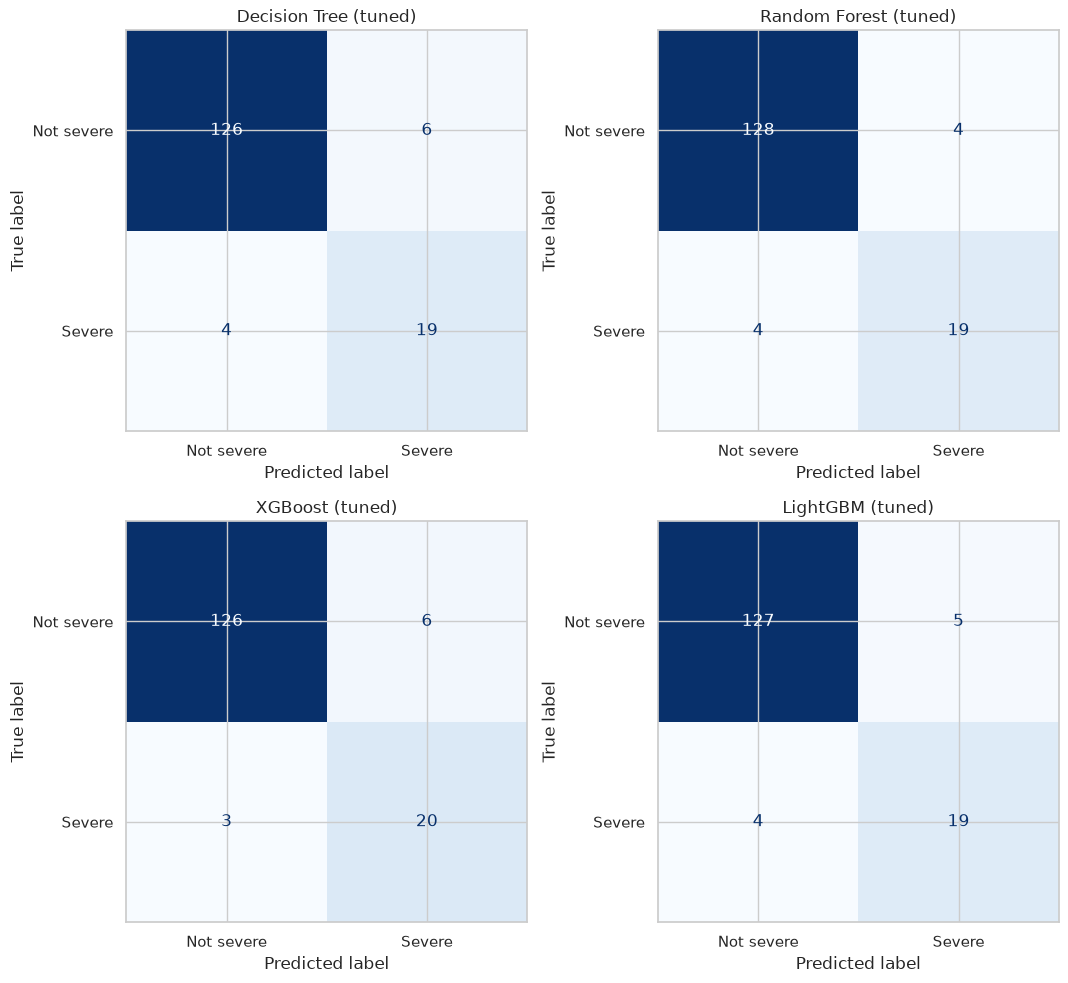

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, final_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not severe", "Severe"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [33]:
# Same info as a table, with FN highlighted since it's the clinically costliest error
cm_summary = []
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cm_summary.append({
        "model": name, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "FN_rate": fn / (fn + tp)   # fraction of actual appendicitis cases missed
    })

pd.DataFrame(cm_summary)

,model,TN,FP,FN,TP,FN_rate
0,Decision Tree (tuned),126,6,4,19,0.173913
1,Random Forest (tuned),128,4,4,19,0.173913
2,XGBoost (tuned),126,6,3,20,0.130435
3,LightGBM (tuned),127,5,4,19,0.173913


In [34]:
def get_importance_df(model, feature_names, model_name, importance_type=None):
    if importance_type == "gain":  # XGBoost
        importances = model.get_booster().get_score(importance_type="gain")
        imp_df = pd.DataFrame({
            "feature": list(importances.keys()),
            "importance": list(importances.values())
        })
    else:  # sklearn-style (Decision Tree, Random Forest)
        imp_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        })
    imp_df["model"] = model_name
    return imp_df.sort_values("importance", ascending=False)

In [35]:
imp_dt = get_importance_df(best_dt, X_train.columns, "Decision Tree")
imp_rf = get_importance_df(best_rf, X_train.columns, "Random Forest")
imp_xgb = get_importance_df(best_xgb, X_train.columns, "XGBoost", importance_type="gain")

# Top 15 features for each
print("Decision Tree - Top 15")
display(imp_dt.head(15))

print("\nRandom Forest - Top 15")
display(imp_rf.head(15))

print("\nXGBoost - Top 15")
display(imp_xgb.head(15))

Decision Tree - Top 15


,feature,importance,model
5,Length_of_Stay,0.733559,Decision Tree
28,CRP,0.151023,Decision Tree
17,WBC_Count,0.061074,Decision Tree
23,RDW,0.017010,Decision Tree
34,Free_Fluids,0.016487,Decision Tree
22,Hemoglobin,0.009102,Decision Tree
18,Neutrophil_Percentage,0.006838,Decision Tree
68,Ipsilateral_Rebound_Tenderness_observed,0.004907,Decision Tree
1,BMI,0.000000,Decision Tree
0,Age,0.000000,Decision Tree



Random Forest - Top 15


,feature,importance,model
5,Length_of_Stay,0.496236,Random Forest
28,CRP,0.161410,Random Forest
17,WBC_Count,0.060812,Random Forest
68,Ipsilateral_Rebound_Tenderness_observed,0.028218,Random Forest
32,Ipsilateral_Rebound_Tenderness,0.028103,Random Forest
39,Perforation,0.025181,Random Forest
18,Neutrophil_Percentage,0.024342,Random Forest
1,BMI,0.016857,Random Forest
24,Thrombocyte_Count,0.016653,Random Forest
19,Segmented_Neutrophils,0.011914,Random Forest



XGBoost - Top 15


,feature,importance,model
5,Length_of_Stay,48.482929,XGBoost
41,Ipsilateral_Rebound_Tenderness_observed,13.822734,XGBoost
27,Appendix_Wall_Layers,11.837368,XGBoost
23,CRP,11.716271,XGBoost
17,Neutrophil_Percentage,11.678606,XGBoost
25,Ipsilateral_Rebound_Tenderness,11.191782,XGBoost
34,Meteorism,11.113099,XGBoost
15,Body_Temperature,6.908404,XGBoost
29,Perforation,6.837491,XGBoost
26,Free_Fluids,6.578207,XGBoost
